# Lotka-Volterra: Predator-Prey Dynamics

## What Is It?
The Lotka-Volterra equations model how predator and prey
populations interact over time.

**Real world examples:**
- Rabbits and foxes in a forest
- Fish and sharks in the ocean
- Bacteria and viruses

## The ODE System
`dy1/dt = alpha*y1 - beta*y1*y2  (prey)`
`dy2/dt = delta*y1*y2 - gamma*y2  (predator)`

Where:
- alpha = prey birth rate
- beta  = predation rate
- delta = predator growth from eating prey
- gamma = predator death rate

In [1]:
import sys, os
sys.path.insert(0, os.path.join('..', 'python'))
sys.path.insert(0, os.path.join('..', 'build'))
import numpy as np
import matplotlib.pyplot as plt
from fastode_interface import solve

In [2]:
alpha, beta, delta, gamma = 1.0, 0.1, 0.075, 1.5

def lotka_volterra(t, y):
    rabbits, foxes = y[0], y[1]
    drabbits = alpha*rabbits - beta*rabbits*foxes
    dfoxes   = delta*rabbits*foxes - gamma*foxes
    return [drabbits, dfoxes]

result = solve(lotka_volterra, t0=0, t1=40,
               y0=[10.0, 5.0], method='RK45')

print(f'Steps: {result.n_steps}, Rejected: {result.n_rejected}')
print(f'Time points: {len(result.t)}')

Steps: 185, Rejected: 43
Time points: 186


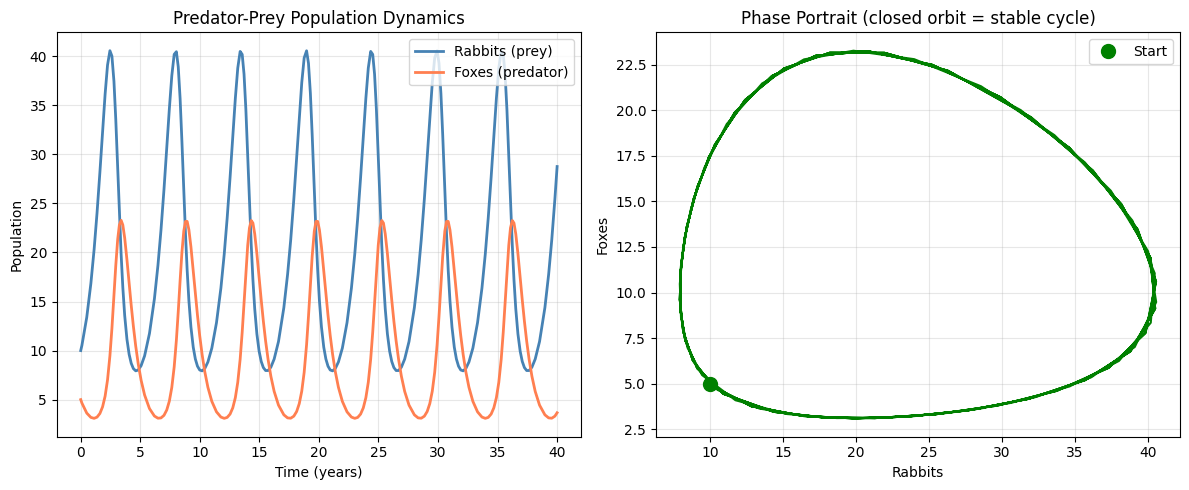

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(result.t, result.y[0],
             color='steelblue', linewidth=2, label='Rabbits (prey)')
axes[0].plot(result.t, result.y[1],
             color='coral', linewidth=2, label='Foxes (predator)')
axes[0].set_xlabel('Time (years)')
axes[0].set_ylabel('Population')
axes[0].set_title('Predator-Prey Population Dynamics')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(result.y[0], result.y[1], color='green', linewidth=1.5)
axes[1].plot(result.y[0,0], result.y[1,0], 'go', markersize=10,
             label='Start')
axes[1].set_xlabel('Rabbits')
axes[1].set_ylabel('Foxes')
axes[1].set_title('Phase Portrait (closed orbit = stable cycle)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('lotka_volterra.png', dpi=100)
plt.show()

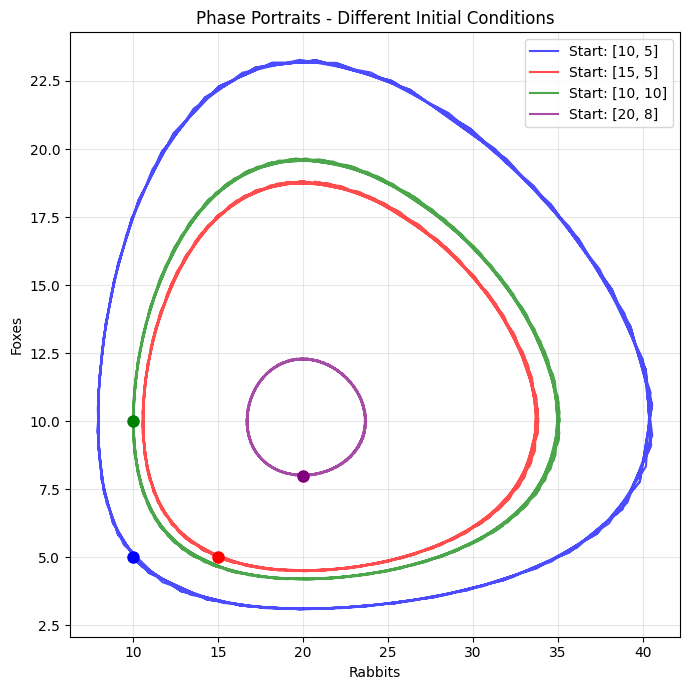

In [4]:
fig, ax = plt.subplots(figsize=(7, 7))

initial_conditions = [
    ([10, 5],  'blue'),
    ([15, 5],  'red'),
    ([10, 10], 'green'),
    ([20, 8],  'purple'),
]

for y0, color in initial_conditions:
    r = solve(lotka_volterra, t0=0, t1=40,
              y0=y0, method='RK45')
    ax.plot(r.y[0], r.y[1], color=color,
            alpha=0.7, linewidth=1.5, label=f'Start: {y0}')
    ax.plot(r.y[0,0], r.y[1,0], 'o', color=color, markersize=8)

ax.set_xlabel('Rabbits')
ax.set_ylabel('Foxes')
ax.set_title('Phase Portraits - Different Initial Conditions')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()